# Landauer–Büttiker transport in PAOFLOW — Al wire with a single H impurity

Builds the publication figure for `example02`: an Al monatomic wire bridged by one
hydrogen atom, treated as a left-lead / conductor / right-lead (LCR) scattering problem.

The figure has four panels:

- **(a)** device schematic with the L / C / R partition and the lead self-energies
- **(b)** transmission $T(E)$ — the pristine wire's quantized staircase against the junction
- **(c)** conductor density of states
- **(d)** current–voltage characteristic with the differential conductance

All data is read from `Reference/`; nothing needs to be recomputed.

Two conventions in the PAOFLOW output are easy to get wrong and are handled explicitly below:

1. Energies are **already referenced to the Fermi level** — `inputs/read_QE_xml.py`
   subtracts $E_\mathrm{F}$ from the eigenvalues, so $E = 0$ is $E_\mathrm{F}$.
2. `conductance_*.dat` writes **one channel label too many** in its header, so columns
   are indexed positionally rather than by name.

In [64]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator

# Resolve paths relative to the notebook, with a fallback for kernels started elsewhere.
HERE = Path.cwd()
if not (HERE / 'output/paoflow').is_dir():
    HERE = Path('examples/transport_examples/example02').resolve()
REF = HERE / 'output/paoflow'
OUT = HERE / 'landauer_example02.png'

# Colour-blind-safe palette, one colour per physical system.
BLUE = '#004488'    # pristine Al wire (lead)
VERM = '#D55E00'    # Al-H-Al junction
AMBER = '#FFC20A'   # annotations: E_F marker, dI/dV
AMBER_TXT = '#C08A00'  # amber darkened just enough to read on white

# Shared typography so all panels read the same way.
TEXT_FS = 8.8
LEGEND_FS = 8.8
PANEL_FS = 9.0
TEXT_WEIGHT = 'semibold'

# current.dat holds the bare integral of T(E)[f_L - f_R] dE with T in units of
# 2e^2/h and E in eV, i.e. units of G0 * 1 V. No prefactor is applied in the code.
UA_PER_UNIT = 77.4809  # microamperes per (2e^2/h) * V

# Upper edge clips a band-edge numerical artefact above ~1.85 eV.
EMIN, EMAX = -6.5, 1.75

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': TEXT_FS,
    'font.weight': TEXT_WEIGHT,
    'axes.labelsize': TEXT_FS,
    'axes.labelweight': TEXT_WEIGHT,
    'axes.titleweight': TEXT_WEIGHT,
    'xtick.labelsize': 8.2,
    'ytick.labelsize': 8.2,
    'axes.linewidth': 0.7,
    'lines.linewidth': 1.0,
    'xtick.major.width': 0.7,
    'ytick.major.width': 0.7,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'legend.frameon': False,
    'legend.fontsize': LEGEND_FS,
    'figure.dpi': 130,
})

## Load the transport data

In [ ]:
# Columns indexed positionally: E, T_total, then the eigenchannels.
t_lead = np.loadtxt(REF / 'conductance_lead.dat')   # E, T
t_lcr = np.loadtxt(REF / 'conductance_lcr.dat')     # E, T_total, ch1..ch4
d_lead = np.loadtxt(REF / 'doscond_lead.dat')       # E, DOS
d_lcr = np.loadtxt(REF / 'doscond_lcr.dat')         # E, DOS
iv = np.loadtxt(REF / 'current.dat')                # V, I in (2e^2/h)*V


def at_fermi(data):
    """Value of column 1 at the row closest to E = 0."""
    return data[np.argmin(np.abs(data[:, 0])), 1]


T_LEAD_EF = at_fermi(t_lead)
T_LCR_EF = at_fermi(t_lcr)
CH_EF = t_lcr[np.argmin(np.abs(t_lcr[:, 0])), 2:]

print(f'T at E_F:  pristine lead {T_LEAD_EF:.3f}   junction {T_LCR_EF:.3f}'
      f'   ({100 * (1 - T_LCR_EF / T_LEAD_EF):.0f}% suppression)')
print(f'junction eigenchannels at E_F: {np.round(CH_EF, 3)}')
print(f'I at V = 1 V: {iv[-1, 1] * UA_PER_UNIT:.1f} uA')

# Guard against the underlying data being regenerated with a different story.
assert abs(T_LEAD_EF - 1.99) < 0.05, T_LEAD_EF
assert abs(T_LCR_EF - 1.33) < 0.05, T_LCR_EF

T at E_F:  pristine lead 1.994   junction 1.333   (33% suppression)
junction eigenchannels at E_F: [0.982 0.352 0.    0.   ]
I at V = 1 V: 74.6 uA


: 

## Geometry for the schematic

In [ ]:
def parse_scf_positions(path):
    """Return (symbols, Nx3 coords) from the ATOMIC_POSITIONS block of a QE input."""
    lines = path.read_text().splitlines()
    start = next(i for i, line in enumerate(lines)
                 if line.strip().upper().startswith('ATOMIC_POSITIONS'))
    symbols, coords = [], []
    for line in lines[start + 1:]:
        fields = line.split()
        if len(fields) < 4 or not re.fullmatch(r'[A-Z][a-z]?', fields[0]):
            break
        symbols.append(fields[0])
        coords.append([float(v) for v in fields[1:4]])
    return symbols, np.array(coords)


SYMBOLS, POS = parse_scf_positions(HERE / 'scf.in')
print(f'{len(SYMBOLS)} atoms, species {sorted(set(SYMBOLS))}')
print(f'chain spans z = {POS[:, 2].min():.3f} to {POS[:, 2].max():.3f} alat')

11 atoms, species ['Al', 'H']
chain spans z = -0.750 to 2.625 alat


: 

## Panels

In [79]:
def panel_schematic(ax):
    """Ball-and-stick device schematic with the L / C / R transport partition."""
    z, x = POS[:, 2], POS[:, 0]
    is_h = np.array([s == 'H' for s in SYMBOLS])

    # Layers group by distinct z; define_partition takes 3 layers at each end.
    order = np.argsort(z)
    left, right = order[:3], order[-3:]

    dz = 0.375  # Al-Al spacing along the chain, in units of alat
    zl, zr = z[order[0]], z[order[-1]]

    # Semi-infinite leads: fading repeat atoms beyond the explicit cell.
    for k in (1, 2, 3):
        for zz in (zl - k * dz, zr + k * dz):
            ax.plot([zz], [0.0], 'o', ms=6.5, mfc=BLUE, mec='none',
                    alpha=0.42 / k, zorder=2)

    # Region shading and labels, as a bounded band rather than the full panel.
    pad = 0.19
    band_lo, band_hi = -0.62, 0.62
    spans = [(zl - 3.5 * dz, z[left[-1]] + pad, BLUE, 'L'),
             (z[left[-1]] + pad, z[right[0]] - pad, VERM, 'C'),
             (z[right[0]] - pad, zr + 3.5 * dz, BLUE, 'R')]
    for za, zb, colour, label in spans:
        ax.add_patch(Rectangle((za, band_lo), zb - za, band_hi - band_lo,
                               facecolor=colour, alpha=0.09, lw=0, zorder=0))
        ax.text(0.5 * (za + zb), 0.46, label, ha='center', va='center',
                fontsize=TEXT_FS, color=colour, fontweight=TEXT_WEIGHT)

    # Bonds: the Al backbone, then the two Al-H bonds.
    chain = [i for i in order if not is_h[i]]
    for a, b in zip(chain[:-1], chain[1:]):
        ax.plot([z[a], z[b]], [x[a], x[b]], '-', color='0.55', lw=0.9, zorder=1)
    h = int(np.flatnonzero(is_h)[0])
    for nb in np.argsort(np.abs(z - z[h]))[1:3]:
        ax.plot([z[h], z[nb]], [x[h], x[nb]], '-', color='0.55', lw=0.9, zorder=1)

    # Atoms.
    for i in range(len(z)):
        ax.plot([z[i]], [x[i]], 'o', ms=5.5 if is_h[i] else 7.5,
                mfc=VERM if is_h[i] else BLUE, mec='white', mew=0.6, zorder=3)
    # ax.text(z[h] + 0.13, x[h], 'H', fontsize=7.5, color=VERM,
    #         ha='left', va='center')

    # Lead self-energies, drawn inside the shaded lead regions.
    for zt, zh, label in ((zl - 2.7 * dz, zl - 0.55 * dz, r'$\Sigma_L$'),
                          (zr + 2.7 * dz, zr + 0.55 * dz, r'$\Sigma_R$')):
        ax.annotate('', xy=(zh, -0.42), xytext=(zt, -0.42),
                    arrowprops=dict(arrowstyle='->', color='0.35', lw=1.1, mutation_scale=12))
        ax.text(0.5 * (zt + zh), -0.36, label, ha='center', va='bottom',
                fontsize=TEXT_FS, color='0.25', fontweight=TEXT_WEIGHT)

    # ax.text(0.5 * (zl + zr), -0.83, r'transport direction $z$', ha='center',
    #         va='center', fontsize=7, color='0.4')
    ax.set_xlim(zl - 3.7 * dz, zr + 3.7 * dz)
    ax.set_ylim(-1.02, 0.80)
    ax.axis('off')



def colour_legend(ax, handles, colours, **kwargs):
    """Frameless legend whose label text is tinted to match its curve."""
    opts = dict(loc='upper left', fontsize=LEGEND_FS, handlelength=1.5,
                handletextpad=0.5, labelspacing=0.28, borderaxespad=0.25)
    opts.update(kwargs)
    leg = ax.legend(handles=handles, **opts)
    for text, colour in zip(leg.get_texts(), colours):
        text.set_color(colour)
        text.set_fontsize(LEGEND_FS)
        text.set_fontweight(TEXT_WEIGHT)
    return leg



def panel_transmission(ax):
    """Transmission of the pristine wire against the H-bridged junction."""
    ax.axvline(0.0, color="black", linestyle=':', lw=0.9, zorder=1)
    lead, = ax.plot(t_lead[:, 0], t_lead[:, 1], color=BLUE, lw=1.1, zorder=3,
                    label='pristine Al wire')
    lcr, = ax.plot(t_lcr[:, 0], t_lcr[:, 1], color=VERM, lw=1.0, zorder=4,
                   label=r'Al$-$H$-$Al junction')

    ax.set_xlim(EMIN, EMAX)
    ax.set_ylim(0, 3.5)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel(r'$T(E)$ ($2e^{2}/h$)', fontsize=TEXT_FS, fontweight=TEXT_WEIGHT)
    ax.tick_params(labelbottom=False)

    # Legend in the empty upper-left block, in place of a boxed legend.
    colour_legend(ax, [lead, lcr], (BLUE, VERM))
    ax.text(0.16, 3.18, r'$E_\mathrm{F}$', color="black", fontsize=TEXT_FS, va='center', fontweight=TEXT_WEIGHT)

    # The transmission gap just below E_F is empty, so the E_F values are
    # annotated there rather than crammed against the right-hand edge.
    # leader = dict(arrowstyle='-', lw=0.6, shrinkA=1, shrinkB=2)
    # for value, colour, ytext in ((T_LEAD_EF, BLUE, 2.30), (T_LCR_EF, VERM, 0.72)):
    #     ax.plot([0.0], [value], 'o', ms=2.6, color=colour, zorder=5)
    #     ax.annotate(f'{value:.2f}', xy=(-0.04, value), xytext=(-0.30, ytext),
    #                 fontsize=7, color=colour, va='center', ha='right',
    #                 arrowprops=dict(leader, color=colour))



def panel_dos(ax):
    """Conductor density of states, sharing the energy axis with the T(E) panel."""
    def window(data):
        return data[(data[:, 0] >= EMIN) & (data[:, 0] <= EMAX)]

    wl, wc = window(d_lead), window(d_lcr)
    top = np.percentile(np.concatenate([wl[:, 1], wc[:, 1]]), 98)

    ax.axvline(0.0, color="black", linestyle=':', lw=0.9, zorder=1)
    ax.plot(wl[:, 0], wl[:, 1], color=BLUE, lw=1.0, zorder=3)
    ax.plot(wc[:, 0], wc[:, 1], color=VERM, lw=0.9, zorder=4)

    ax.set_xlim(EMIN, EMAX)
    ax.set_ylim(0, top)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3, integer=True, prune='upper'))
    ax.set_xlabel(r'$E - E_\mathrm{F}$ (eV)', fontsize=TEXT_FS, fontweight=TEXT_WEIGHT)
    ax.set_ylabel('DOS\n(states/eV)', fontsize=TEXT_FS, fontweight=TEXT_WEIGHT)
    return top



def panel_current(ax):
    """Landauer I(V) of the junction, with the differential conductance."""
    v = iv[:, 0]
    current = iv[:, 1] * UA_PER_UNIT

    ax.axhline(0.0, color='0.85', lw=0.6, zorder=0)
    ax.axvline(0.0, color='0.85', lw=0.6, zorder=0)
    curr, = ax.plot(v, current, color=VERM, lw=1.3, zorder=3, label=r'$I$')

    ax.set_xlim(-1, 1)
    ax.set_ylim(-85, 85)
    ax.set_xlabel(r'bias  voltage (V)', fontsize=TEXT_FS, fontweight=TEXT_WEIGHT)
    # Label and ticks tucked in against the spine; the width freed on the left of
    # this panel is what lets the centre column grow.
    ax.set_ylabel(r'$I$ ($\mu$A)', color=VERM, labelpad=1, fontsize=TEXT_FS, fontweight=TEXT_WEIGHT)
    ax.tick_params(axis='y', colors=VERM, pad=1.5)
    ax.spines['left'].set_color(VERM)

    # Differential conductance, lightly smoothed to tame the numerical derivative.
    axg = ax.twinx()
    k = 15
    g = np.gradient(current, v) / UA_PER_UNIT
    g = np.convolve(g, np.ones(k) / k, mode='same')
    cond, = axg.plot(v[k:-k], g[k:-k], '--', color=AMBER, lw=1.8, zorder=2,
                     label='dI/dV')
    axg.set_ylim(0, 1.35 * g[k:-k].max())
    axg.set_ylabel(r'$dI/dV$ ($2e^{2}/h$)', color=AMBER_TXT, fontsize=TEXT_FS, fontweight=TEXT_WEIGHT)
    axg.tick_params(axis='y', colors=AMBER_TXT)
    axg.spines['right'].set_color(AMBER_TXT)
    axg.spines['left'].set_color(VERM)

    # One legend for both axes, drawn on the twin so it sits above every curve.
    leg = colour_legend(axg, [curr, cond], (VERM, AMBER_TXT), fontsize=LEGEND_FS)
    for text in leg.get_texts():
        text.set_fontweight(TEXT_WEIGHT)
    return axg

## Assemble and save

In [80]:
# fig = plt.figure(figsize=(7.0, 2.75))
# # (d) now keeps its y label tight against the spine, so the inter-panel gaps can
# # shrink; the width that frees goes to the centre column, not to (a)'s atoms.
# gs = GridSpec(2, 3, figure=fig, width_ratios=[1.24, 1.46, 1.0],
#               height_ratios=[1.75, 1.0], wspace=0.40, hspace=0.16,
#               left=0.030, right=0.918, top=0.92, bottom=0.17)

# ax_a = fig.add_subplot(gs[:, 0])
# ax_b = fig.add_subplot(gs[0, 1])
# ax_c = fig.add_subplot(gs[1, 1], sharex=ax_b)
# ax_d = fig.add_subplot(gs[:, 2])

# panel_schematic(ax_a)
# panel_transmission(ax_b)
# dos_top = panel_dos(ax_c)
# panel_current(ax_d)

# for ax, letter, dx, dy in ((ax_a, '(a)', 0.00, 1.00),
#                            (ax_b, '(b)', -0.20, 1.14),
#                            (ax_c, '(c)', -0.20, 1.22),
#                            (ax_d, '(d)', -0.24, 1.06)):
#     ax.text(dx, dy, letter, transform=ax.transAxes, fontsize=PANEL_FS,
#             fontweight=TEXT_WEIGHT, ha='left', va='top')

# SAVE_DPI = 1200  # publication-grade raster export
# fig.savefig(OUT, dpi=SAVE_DPI, bbox_inches='tight', facecolor='white', pad_inches=0.01)
# print(f'wrote {OUT} at {SAVE_DPI} dpi  (DOS clipped at {dos_top:.1f} states/eV)')
# plt.show()

wrote /home/anooja/Work/software/PAOFLOW/examples/transport_examples/example02/landauer_example02_2panel_inset.png at 1200 dpi


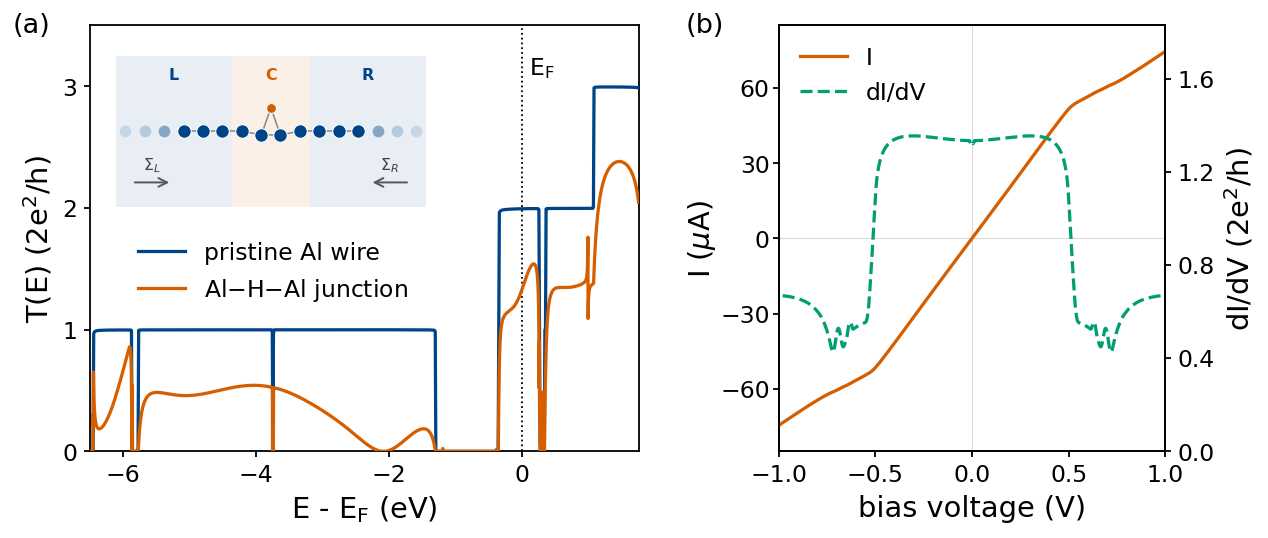

In [84]:
# Two-panel variant in the style of the attached reference image
OUT_2P = HERE / 'landauer_example02_2panel_inset.png'

# Match the attached-image typography: sans-serif, larger labels/ticks, normal weight.
img_style = {
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'mathtext.fontset': 'dejavusans',
    'font.size': 13,
    'font.weight': 'normal',
    'axes.labelsize': 16,
    'axes.labelweight': 'normal',
    'axes.linewidth': 1.0,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'lines.linewidth': 1.8,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'legend.frameon': False,
    'legend.fontsize': 13,
    'figure.dpi': 130,

}

with plt.rc_context(img_style):
    fig = plt.figure(figsize=(9.4, 4.2))
    gs = GridSpec(
        1,
        2,
        figure=fig,
        width_ratios=[1.42, 1.00],
        wspace=0.30,
        left=0.08,
        right=0.96,
        top=0.94,
        bottom=0.16,
    )

    ax_t = fig.add_subplot(gs[0, 0])
    ax_i = fig.add_subplot(gs[0, 1])

    # Transmission panel.
    ax_t.axvline(0.0, color='black', linestyle=':', lw=1.0, zorder=1)
    lead, = ax_t.plot(
        t_lead[:, 0],
        t_lead[:, 1],
        color=BLUE,
        # lw=2.2,
        label='pristine Al wire',
        zorder=3,
    )
    lcr, = ax_t.plot(
        t_lcr[:, 0],
        t_lcr[:, 1],
        color=VERM,
        # lw=2.2,
        label=r'Al$-$H$-$Al junction',
        zorder=4,
    )

    ax_t.set_xlim(EMIN, EMAX)
    ax_t.set_ylim(0, 3.5)
    ax_t.set_yticks([0, 1, 2, 3])
    ax_t.set_xlabel(r'E - E$_\mathrm{F}$ (eV)')
    ax_t.set_ylabel(r'T(E) (2e$^{2}$/h)')
    ax_t.text(0.10, 3.15, r'E$_\mathrm{F}$', color='black', va='center')

    # LCR inset inside transmission panel.
    ax_in = ax_t.inset_axes([0.04, 0.46, 0.58, 0.52])
    panel_schematic(ax_in)
    ax_in.patch.set_facecolor('white')
    ax_in.patch.set_alpha(0.92)

    # Keep legend inside panel.
    ax_t.legend(loc='center left', bbox_to_anchor=(0.05, 0.42), handlelength=2.0)

    # I(V) panel with dI/dV.
    axg = panel_current(ax_i)

    # panel_current sets compact publication fonts/weights for the 4-panel layout;
    # restore this 2-panel style explicitly so panel labels match panel (a).
    label_size = img_style['axes.labelsize']
    label_weight = img_style['axes.labelweight']
    tick_size = img_style['ytick.labelsize']

    ax_i.set_xlabel('bias voltage (V)', fontsize=label_size, fontweight=label_weight)

    # Use a separate colorblind-friendly color for dI/dV to avoid
    # visual association with the pristine/junction colors in panel (a).
    DIDV_COLOR = '#009E73'

    # Match I exactly to the junction transmission style in panel (a),
    # and keep dI/dV at the same line width as I.
    curr_line = ax_i.lines[-1]
    didv_line = axg.lines[-1]
    curr_line.set_color(lcr.get_color())
    curr_line.set_linewidth(lcr.get_linewidth())
    didv_line.set_color(DIDV_COLOR)
    didv_line.set_linestyle('--')
    didv_line.set_linewidth(curr_line.get_linewidth())

    # Use neutral axis-label/tick styling, as in panel 1.
    ax_i.set_ylabel(r'I ($\mu$A)', color='black', fontsize=label_size, fontweight=label_weight)
    ax_i.tick_params(axis='x', colors='black', labelsize=img_style['xtick.labelsize'])
    ax_i.tick_params(axis='y', colors='black', labelsize=tick_size)
    ax_i.spines['left'].set_color('black')

    axg.set_ylabel(r'dI/dV (2e$^{2}$/h)', color='black', fontsize=label_size, fontweight=label_weight)
    axg.tick_params(axis='y', colors='black', labelsize=tick_size)
    axg.spines['right'].set_color('black')
    axg.spines['left'].set_color('black')

    # Replace panel_current legend with a panel-1-consistent legend.
    axg.legend([curr_line, didv_line], ['I', 'dI/dV'],
              loc='upper left', handlelength=2.0)

    # Larger panel labels.
    ax_t.text(-0.14, 1.03, '(a)', transform=ax_t.transAxes, fontsize=15, ha='left', va='top')
    ax_i.text(-0.24, 1.03, '(b)', transform=ax_i.transAxes, fontsize=15, ha='left', va='top')

    from matplotlib.ticker import MaxNLocator

    # Reduce the number of y-axis ticks in panel (b)
    ax_i.yaxis.set_major_locator(MaxNLocator(nbins=6))
    axg.yaxis.set_major_locator(MaxNLocator(nbins=6))

    SAVE_DPI = 1200
    fig.savefig(OUT_2P, dpi=SAVE_DPI, bbox_inches='tight', facecolor='white', pad_inches=0.01)
    print(f'wrote {OUT_2P} at {SAVE_DPI} dpi')
    plt.show()
